# 첫 번째 머신러닝 만들어 보기 - 붓꽃 품종 예측하기

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd

# 붓꽃 데이터 세트를 로딩합니다.
iris = load_iris()

# iris_data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있다
iris_data = iris.data

# iris_target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있다
iris_label = iris.target
print("iris target값 :", iris_label)
print("iris target명 :", iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환한다
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df["label"] = iris.target
iris_df.head(3)

iris target값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명 : ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


학습 데이터로 학습된 모델이 얼마나 뛰어난 성능을 가지는 평가하기 위해서 학습용 데이터와 테스트용 데이터를 반드시 분리해야 합니다.

이를 위해서 사이킷런은 train_test_split() API를 제공합니다

In [3]:
x_train, x_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size=0.2, random_state=11)

In [4]:
# DecisionTreeClassifier 객체 생성
dt_clf = DecisionTreeClassifier(random_state = 11)

# 학습 수행
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=11)

DecisionTreeClassifier 객체는 학습 데이터를 기반으로 학습이 완료되었습니다.
이렇게 학습된 DecisionTreeClassifier 객체를 이용해 예측을 수행합니다.

예측은 반드시 학습 데이터가 아닌 다른 데이터를 이용해야 하며, 일반적으로 테스트 데이터 세트를 이용합니다.

In [5]:
# 학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행
pred = dt_clf.predict(x_test)

일반적으로 머신러닝 모델의 성능 평가 방법은 여러 가지가 잇으나, 여기서는 정확도를 측정해보겠습니다.

In [6]:
from sklearn.metrics import accuracy_score
print("예측 정확도 : {0:.4f}".format(accuracy_score(y_test, pred)))

예측 정확도 : 0.9333


In [7]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data))

<class 'sklearn.utils._bunch.Bunch'>


In [8]:
# 데이터 세트에 내장돼 있는 대부분의 데이터 세트는 딕셔너리 형태의 값을 반환합니다.
# 딕셔너리 형태이므로 load_iris() 데이터 세트의 key 값 출력하기
keys = iris_data.keys()
print("붓꽃 데이터 세트의 키들 :", keys)

붓꽃 데이터 세트의 키들 : dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [9]:
print("\n feature_names의 type :", type(iris_data.feature_names))
print(" feature_names의 shape :", len(iris_data.feature_names))
print(iris_data.feature_names)

print("\n target_names의 type :", type(iris_data.target_names))
print(" target_names의 shape :", len(iris_data.target_names))
print(iris_data.target_names)

print("\n data의 type :", type(iris_data.data))
print(" data의 shape :", iris_data.data.shape)
print(iris_data["data"])

print("\n target의 type", type(iris_data.target))
print(" target의 shape :", iris_data.target.shape)
print(iris_data.target)


 feature_names의 type : <class 'list'>
 feature_names의 shape : 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type : <class 'numpy.ndarray'>
 target_names의 shape : 3
['setosa' 'versicolor' 'virginica']

 data의 type : <class 'numpy.ndarray'>
 data의 shape : (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.

## 학습 / 테스트 데이터 세트 분리 - train_test_split()

In [10]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
dt_clf = DecisionTreeClassifier()
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data, train_label)

# 핛브 데이터 세트으로 예측 수행
pred = dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label, pred))

예측 정확도: 1.0


현재 정확도가 100%가 나옵니다.
예측 결과가 100% 정확한 이유는 이미 학습한 학습 데이터 세트를 기반으로 예측했기 때문입니다.

따라서 붓꽃 데이터 세트를 train_test_split()을 이용해 테스트 데이터 세트를 전체의 30%, 학습 데이터 세트를 70%로 분리하여 진행하겠습니다.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()

x_train, x_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size = 0.3, random_state = 121)

In [12]:
dt_clf.fit(x_train, y_train)
pred = dt_clf.predict(x_test)
print("예측 정확도 :{0:.4f}".format(accuracy_score(y_test, pred)))

예측 정확도 :0.9556


## 교차 검증 / K 폴드 교차 검증

교차 검증은 데이터 편중을 막기 위해 별도의 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습과 평가를 수행하는 것을 말합니다.

K 폴드 교차 검증은 가장 보편적으로 사용되는 교차 검증 기법입니다.
먼저 K개의 데이터 폴드 세트를 만들어서 K번만큼 각 폴트 세트에 학습과 검증 평가를 반복적으로 수행하는 방법입니다

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state = 156)

# 5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성
kfold = KFold(n_splits = 5)
cv_accuracy = []
print("붓꽃 데이터 세트 크기 :", features.shape[0])

붓꽃 데이터 세트 크기 : 150


In [14]:
n_iter = 0

# Kfold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):
    # kfold.split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    x_train, x_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    # 학습 및 예측
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    # 반복 시마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    print("\n{0} 교차 검증 정확도 : {1}, gkrtqm epdlxj zmrl : {2}, 검증 데이터 크기 : {3}".format(n_iter, accuracy, train_size, test_size))
    print("#{0} 검증 세트 인덱스 : {1}".format(n_iter, test_index))
    cv_accuracy.append(accuracy)

# 개별 iteration별 정확도를 합하여 평균 정확도 계산
print("\n## 평균 검증 정확도 : ", np.mean(cv_accuracy))


1 교차 검증 정확도 : 1.0, gkrtqm epdlxj zmrl : 120, 검증 데이터 크기 : 30
#1 검증 세트 인덱스 : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

2 교차 검증 정확도 : 0.9667, gkrtqm epdlxj zmrl : 120, 검증 데이터 크기 : 30
#2 검증 세트 인덱스 : [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

3 교차 검증 정확도 : 0.8667, gkrtqm epdlxj zmrl : 120, 검증 데이터 크기 : 30
#3 검증 세트 인덱스 : [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

4 교차 검증 정확도 : 0.9333, gkrtqm epdlxj zmrl : 120, 검증 데이터 크기 : 30
#4 검증 세트 인덱스 : [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

5 교차 검증 정확도 : 0.7333, gkrtqm epdlxj zmrl : 120, 검증 데이터 크기 : 30
#5 검증 세트 인덱스 : [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도 :  0.9


### Stratified K 폴드
Stratified K 폴드 불균형한 분포도를 가진 레이블 데이터 집합을 위한 K 폴드 방식입니다. 불균형ㅎ나 분포도를 가진 레이블 데이터 집합은 특정 레이블 값이 특이하게 많거나 매우 적어서 값의 분포가 한쪽으로 치우치는 것을 말합니다.

In [15]:
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df["label"] = iris.target
iris_df["label"].value_counts()

,count
label,
0,50
1,50
2,50


In [16]:
kfold = KFold(n_splits = 3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter += 1
    label_train = iris_df["label"].iloc[train_index]
    label_test = iris_df["label"].iloc[test_index]
    print("## 교차 검증 :{0}".format(n_iter))
    print("학습 레이블 데이터 분포:\n", label_train.value_counts())
    print("검증 레이블 데이터 분포:\n", label_test.value_counts())

## 교차 검증 :1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차 검증 :2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차 검증 :3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


KFold로 분할된 레이블 데이터 세트가 전체 레이블 값의 분포도를 반영하지 못하는 문제가 생깁니다.

StratifiedKFold는 이렇게 KFold로 분할 시 발생하는 값의 분포도를 반영 문제를 해결 할 수 있습니다.
  - StratifiedKFold는 레이블 데이터 분포도에 따라 학습 / 검증 데이터를 나누기 때문에 split()메서드에 인자로 피처 데이터 세트뿐만 아니라 레이블 데이터 세트도 반드시 필요합니다

In [17]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits = 3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df["label"]):
    n_iter += 1
    label_train = iris_df["label"].iloc[train_index]
    label_test = iris_df["label"].iloc[test_index]

    print("## 교차 검증 : {0}".format(n_iter))
    print("학습 레이블 데이터 분포 :\n", label_train.value_counts())
    print("검증 레이블 데이터 분포 :\n", label_test.value_counts())

## 교차 검증 : 1
학습 레이블 데이터 분포 :
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포 :
 label
0    17
1    17
2    16
Name: count, dtype: int64
## 교차 검증 : 2
학습 레이블 데이터 분포 :
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포 :
 label
0    17
2    17
1    16
Name: count, dtype: int64
## 교차 검증 : 3
학습 레이블 데이터 분포 :
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포 :
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [18]:
dt_clf = DecisionTreeClassifier(random_state = 156)

skfold = StratifiedKFold(n_splits = 3)
n_iter = 0
cv_accuracy = []

# StratifiedKFold의 split() 호출시 반드시 레이블 데이터 세트도 추가 입력 필요
for train_index, test_index in skfold.split(features, label):
    # split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    x_train, x_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    # 학습 및 예측
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)

    # 반복 시마다 정확도 측정
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    print("\n{0} 교차 검증 정확도 :{1}, 학습 데이터 크기 :{2}, 검증 데이터 크기 : {3}".format(n_iter, accuracy, train_size, test_size))
    print("#{0} 검증 세트 인덱스 : {1}".format(n_iter, test_index))
    cv_accuracy.append(accuracy)

# 교차 검증별 정확도 및 평균 정확도 계산
print("\n## 교차 검증별 정확도 : ", np.round(cv_accuracy, 4))
print("## 평균 검증 정확도 : ", np.round(np.mean(cv_accuracy), 4))


1 교차 검증 정확도 :0.98, 학습 데이터 크기 :100, 검증 데이터 크기 : 50
#1 검증 세트 인덱스 : [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

2 교차 검증 정확도 :0.94, 학습 데이터 크기 :100, 검증 데이터 크기 : 50
#2 검증 세트 인덱스 : [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

3 교차 검증 정확도 :0.98, 학습 데이터 크기 :100, 검증 데이터 크기 : 50
#3 검증 세트 인덱스 : [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도 :  [0.98 0.94 0.98]
## 평균 검증 정확도 :  0.9667


### 교차 검증을 보다 간편하게 - cross_val_score()
 - 사이킷런에서는 교차 검증을 좀 더 편리하게 수행할 수 있게 해주는 API를 제공합니다
 cross_val_score()는 kfold의 과정을 한꺼번에 수행합니다.

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state = 156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(accuracy), 교차 검증 세트는 3개
scores = cross_val_score(dt_clf, data, label, scoring = "accuracy", cv = 3)
print("교차 검증별 정확도 :", np.round(scores, 4))
print("평균 검증 정확도 :", np.round(np.mean(scores),4))

교차 검증별 정확도 : [0.98 0.94 0.98]
평균 검증 정확도 : 0.9667


## GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한번에

In [20]:
grid_parameters = {"max_depth" : [1,2,3],
                   "min_samples_split" : [2,3]}

In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터를 로딩하고 학습 데이터와 테스트 데이터 분리
iris = load_iris()
x_train, x_test, y_trian, y_test = train_test_split(iris_data.data, iris_data.target, test_size = 0.2, random_state = 121)
dtree = DecisionTreeClassifier()

### 파라미터를 딕셔너리 형태로 설정
parameters = {"max_depth" : [1,2,3], "min_samples_split" : [2,3]}

In [22]:
import pandas as pd

# param_grid의 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정
### refit = True가 default임. True이면 가장 좋은 파라미터 설정으로 재학습시킴
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

# 붓꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습 / 평가
grid_dtree.fit(x_train, y_trian)

# GridSearchCV 결과를 추출해 DataFrame으로 변호나
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[["params", "mean_test_score", "rank_test_score", "split0_test_score", "split1_test_score", "split2_test_score"]]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [23]:
print("GridSearchCV 최적 파라미터 :", grid_dtree.best_params_)
print("GridSearchCV 최고 정확도 :{0:.4f}".format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터 : {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도 :0.9750


In [24]:
# GridSearchCV의 refit으로 이미 학습된 estimator 반환
estimator = grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 학습이 됐으므로 별도 학습이 필요 없음
pred = estimator.predict(x_test)
print("테스트 데이터 세트 정확도 : {0:.4f}".format(accuracy_score(y_test, pred)))

테스트 데이터 세트 정확도 : 0.9667


## 데이터 인코딩

### 레이블 인코딩

In [25]:
from sklearn.preprocessing import LabelEncoder

items = ["TV", "냉장고", "전자레인지", "컴퓨터", "선풍기", "선풍기", "믹서", "믹서"]

# LabelEncoder를 객체로 생성한 후, fit()과 transform()으로 레이블 인코딩 수행
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print("인코딩 변환값 :", labels)

인코딩 변환값 : [0 1 4 5 3 3 2 2]


현재 예시는 데이터가 작아서 문자열 값이 어떤 숫자 값으로 인코딩됐는지 직고나적으로 알 수 있지만, 많은 경우에는 이를 알 수 없습니다. 이러한 경우에는 LabelEncoder 객체의 classes_ 속성값으로 확인하면 됩니다

In [26]:
print("인코딩 클래스 :", encoder.classes_)

인코딩 클래스 : ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [27]:
print("디코딩 원본값 :", encoder.inverse_transform([4,5,2,0,1,1,3,3]))

디코딩 원본값 : ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


레이블 인코딩은 간단하게 문자열 값을 숫자형 카테고리 값으로 변호나합니다. 하지만 레이블 인코딩이 일괄적인 숫자 값으로 변환이 되면서 몇몇 ML 알고리즘에는 이를 적용할 경우 예측 성능이 떨어지는 경우가 발생할 수 있습니다.

그 이유는 숫자 값의 경우 크고 작음에 대한 특성이 작용합니다. 즉, 냉장고가 1, 믹서가 2로 변호나되면 특정 ML 알고리즘에서 가중치가 더 부여되거나 더 중요하게 인식할 가능성이 발생합니다.

### 원-핫 인코딩(One-Hot Encoding)
 - 원-핫 인코딩은 피처 값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지 칼럼에는 0을 표시하는 방법입니다.

In [28]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items = ["TV", "냉장고", "전자레인지", "컴퓨터", "선풍기", "선풍기", "믹서", "믹서"]

# 2차원 ndarray로 변환합니다
items = np.array(items).reshape(-1, 1)

# 원-핫 인코딩을 적용합니다
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환
print("원-핫 인코딩 데이터")
print(oh_labels.toarray())
print("원-핫 인코딩 데이터 차원")
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


판다스에는 원-핫 인코딩을 더 쉽게 지원하는 API가 있습니다.
get_dummies()를 이용하면 됩니다.
사이킷런의 OneHotEncoder와 다르게 문자열 카테고리 값을 숫자 형으로 변환할 필요 없이 바로 변환할 수 있습니다.

In [29]:
import pandas as pd

df = pd.DataFrame({"item" : ["TV", "냉장고", "전자레인지", "컴퓨터", "선풍기", "선풍기", "믹서", "믹서"]})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


## 피처 스케일링과 정규화

피처 스케일링이란?
 - 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링이라고 합니다
  * 대표적인 방법으로는 표준화(Standardization)과 정규화(Nomalization)이 있습니다

## StandardScalar

앞에서 설명한 표준화를 쉽게 지원하기 위한 클래스입니다.
즉, 개별 피처를 평균이 0이고, 분산이 1인 값으로 변환합니다.


이렇게 가우시안 정규 분포를 가질 수 있도록 데이터를 변환하는 것은 몇몇 알고리즘에서 매우 중요합니다. 특히 사이킷런에서 구현한 RBF 커널을 이용하는 서포트 벡터 머신(Support Vector Machine)이나 선형 회귀(Linear Regression), 로지스틱 회귀(Logistic Regression)는 데이터가 가우시안 분포를 가지고 있다고 가정하고 구현됐기 때문에 사전에 표준화를 적용하는 것은 예측 성능 향상에 중요한 요소가 될 수 있다.

In [30]:
from sklearn.datasets import load_iris
import pandas as pd
# 붓꽃 데이터 세트를 로딩하고 DataFrame으로 변환합니다
iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data = iris_data, columns = iris.feature_names)

print("feature들의 평균 값")
print(iris_df.mean())
print("\nfeature들의 분산 값")
print(iris_df.var())

feature들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


StandardScaler 객체를 생성한 후에 fit()과 transform() 메서드에 변환 대상 피처 데이터 세트를 입력하고 호출하면 간단하게 변환 가능합니다.

In [31]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()
# StandardScaler로 데이터 세트 변환 fit()과 transform() 호출
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform() 시 스케일 변환된 데이터 세트가 Numpy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns = iris.feature_names)
print("feature들의 평균값")
print(iris_df_scaled.mean())
print("\nfeature들의 분산 값")
print(iris_df_scaled.var())

feature들의 평균값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


## MinMaxScaler

MinMaxScaler는 데이터값을 0과 1 사이의 범위 값으로 변환합니다.(음수 값이 있으면 -1에서 1값으로 변환합니다)

In [32]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler 객체 생성
scaler = MinMaxScaler()
# MinMaxScaler로 데이터 세트 변환. fit()과 transfrom() 호출
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform()시 스케일 변환된 데이터 세트가 NumPy ndarray로 변환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns = iris.feature_names)
print("feature들의 최솟값")
print(iris_df_scaled.min())
print("\nfeafue들의 최댓값")
print(iris_df_scaled.max())

feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feafue들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


## 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

학습 데이터 세트와 테스트 데이터 세트에 fit()과 transform()을 적용할 때 주의가 필요합니다. Scaler 객체를 이용해 학습 데이터 세트로 fit()과 transform()을 적용하면 테스트 데이터 세트로는 다시 fit()을 수행하지 않고 학습 데이터 세트로 fit()을 수행한 결과를 이용해 transform() 변환을 적용해야 합니다

In [33]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 핛브 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성
# Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경
train_array = np.arange(0,11).reshape(-1,1)
test_array = np.arange(0,6).reshape(-1,1)

In [34]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0-1 값으로 변환
scaler = MinMaxScaler()

# fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 ㅅㄹ정
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10->1로 변환됨
train_scaled = scaler.transform(train_array)

print("원본 train_array 데이터 :", np.round(train_array.reshape(-1),))
print("Scaled된 train)array 데이터 :", np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터 : [ 0  1  2  3  4  5  6  7  8  9 10]
Scaled된 train)array 데이터 : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [35]:
# MinMaxScaler에 tetst_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5 -> 1로 변환
test_scaled = scaler.transform(test_array)

# test_array의 scaled 변환 출력
print("원본 test_array 데이터 :", np.round(test_array.reshape(-1), 2))
print("Scaled된 test_array 데이터 :", np.round(test_scaled.reshape(-1), 2))

원본 test_array 데이터 : [0 1 2 3 4 5]
Scaled된 test_array 데이터 : [0.  0.2 0.4 0.6 0.8 1. ]


In [36]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print("원본 train_array 데이터 :", np.round(train_array.reshape(-1), 2))
print("Scale된 train_array 데이터 :", np.round(train_scaled.reshape(-1), 2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함
test_scaled = scaler.transform(test_array)
print("\n원본 test_array 데이터 :", np.round(test_array.reshape(-1), 2))
print("Scale된 test_rray 데이터 :", np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터 : [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터 : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터 : [0 1 2 3 4 5]
Scale된 test_rray 데이터 : [0.  0.1 0.2 0.3 0.4 0.5]


# 사이킷런으로 수행하는 타이타닉 생존자 예측

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [38]:
titanic_df = pd.read_csv("/content/train (1).csv")
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


타이타닉 탑승자 데이터 설명
 - PassengerId : 탑슺아 데이터 일련번호
 - survived : 생존 여부, 0 = 사망, 1 = 생존
 - pclass : 티켓의 선실 등급, 1 = 일등석, 2 = 이등석, 3 = 삼등석
 - sex : 탑승자 성별
 - name : 탑승자 이름
 - Age : 탑승자 나이
 - SibSp : 같이 탑승한 형제자매 또는 배우자 인원수
 - Parch : 같이 탑승한 부모님 또는 어린이 인원수
 - ticket : 티켓 번호
 - fare : 요금
 - cabin : 선실 번호
 - embarked : 중간 정착 항구

In [39]:
print("\n### 학습 데이터 정보 ### \n")
print(titanic_df.info())


### 학습 데이터 정보 ### 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


현재 Age, Cabin, Embarked 칼럼은 각각 177, 608, 2개의 Null 값을 가지고 있는 상태

* 따라서 Age : 평균, Cabin과 Embarked는 "N" 값으로 변경합니다

In [40]:
titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace = True)
titanic_df["Cabin"].fillna("N", inplace = True)
titanic_df["Embarked"].fillna("N", inplace = True)
print("데이터 서트 Null 값의 개수 :\n", titanic_df.isnull().sum())

데이터 서트 Null 값의 개수 :
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


/tmp/ipykernel_1244/866590183.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace = True)
/tmp/ipykernel_1244/866590183.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [41]:
print("Sex 값 분포 :\n", titanic_df["Sex"].value_counts())
print("\n Cabin 값 분포 :\n", titanic_df["Cabin"].value_counts())
print("\n Embarked 값 분포 :\n", titanic_df["Embarked"].value_counts())

Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


Cabin의 경우 선실 번호 중 선실 등급을 나타내는 첫 번째 알파벳이 가장 중요하다고 판단하여 첫 번째 문자만 추출

In [42]:
titanic_df["Cabin"] = titanic_df["Cabin"].str[:1]
print(titanic_df["Cabin"])

0      N
1      C
2      N
3      C
4      N
      ..
886    N
887    B
888    N
889    C
890    N
Name: Cabin, Length: 891, dtype: object


성별이 생존 확률에 어떤 영향을 미쳤는지, 성별에 따른 생존자 수 비교

In [43]:
titanic_df.groupby(by = ["Sex", "Survived"])["Survived"].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

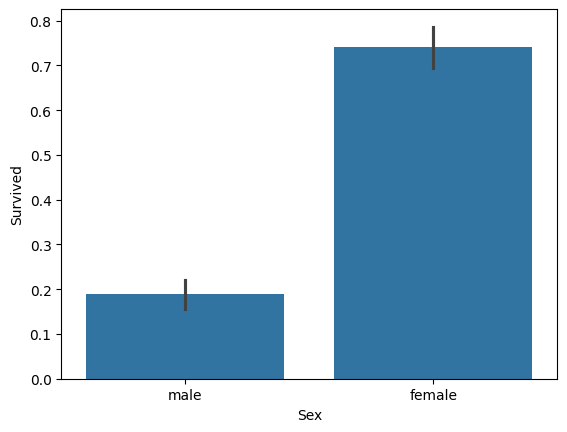

In [44]:
sns.barplot(x = "Sex", y = "Survived", data = titanic_df)

객실 등급에 따른 생존 확률 분석하기

<Axes: xlabel='Pclass', ylabel='Survived'>

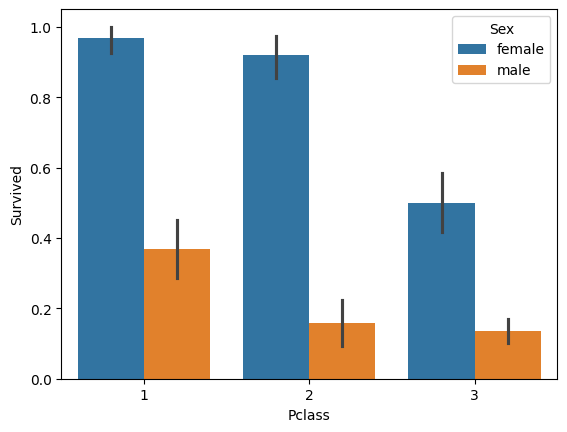

In [45]:
sns.barplot(x = "Pclass", y = "Survived", hue = "Sex", data = titanic_df)

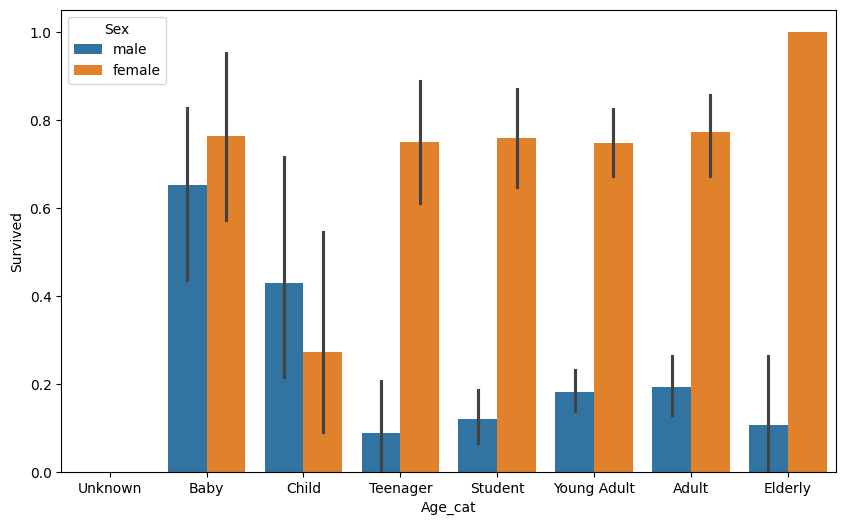

In [46]:
# 입력 age에 따라 구분 값을 반환하는 함수 설정, DataFrame의 apply lambda 식에 사용
def get_category(age):
    cat = ""
    if age <= -1: cat = "Unknown"
    elif age <= 5: cat = "Baby"
    elif age <= 12: cat = "Child"
    elif age <= 18: cat = "Teenager"
    elif age <= 25: cat = "Student"
    elif age <= 35: cat = "Young Adult"
    elif age <= 60: cat = "Adult"
    else: cat = "Elderly"

    return cat

# 막대 그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10, 6))

# x축의 값을 순차적으로 표시하기 위한 설정
group_names = ["Unknown", "Baby", "Child", "Teenager", "Student", "Young Adult", "Adult", "Elderly"]

# lambda 식에 위에서 생성한 get_category() 함수를 반환값으로 지정
# get_category(x)는 입력값으로 'Age' 칼럼 ㄱ밧을 받아서 해당하는 cat 반환
titanic_df["Age_cat"] = titanic_df["Age"].apply(lambda x: get_category(x))
sns.barplot(x = "Age_cat", y = "Survived", hue = "Sex", order = group_names, data = titanic_df)
titanic_df.drop("Age_cat", axis = 1, inplace = True)

남아있는 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환하기(LabelEncoder 클래스 사용)
 * LabelEncoder 객체는 카테고리 값의 유형 수에 따라 0 ~ (카테고리 유형 수 -1)까지의 숫자 값으로 변환됨

In [47]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ["Cabin", "Sex", "Embarked"]
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


지금까지 feature를 가공한 내역을 정리하고 이를 함수로 만들어 쉽게 재사용할 수 있도록 만들기

In [48]:
# Null 처리 함수
def fillna(df):
    df["Age"].fillna(df["Age"].mean(), inplace = True)
    df["Cabin"].fillna("N", inplace = True)
    df["Embarked"].fillna("N", inplace = True)
    df["Fare"].fillna(0, inplace = True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(["PassengerId", "Name", "Ticket"], axis = 1, inplace = True)
    return df

# 레이블 인코딩 수행
def format_features(df):
    df["Cabin"] = df["Cabin"].str[:1]
    features = ["Cabin", "Sex", "Embarked"]
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [49]:
# 원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df = pd.read_csv("/content/train (1).csv")
y_titanic_df = titanic_df["Survived"]
x_titanic_df = titanic_df.drop("Survived", axis = 1)

x_titanic_df = transform_features(x_titanic_df)

/tmp/ipykernel_1244/3474419351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace = True)
/tmp/ipykernel_1244/3474419351.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

내려받은 학습 데이터 세트를 기반으로 해서 train_test_split() API를 이용해 별도의 테스트 데이터 세트를 추출합니다.
 * 테스트 데이터 세트 크기는 전체의 20%로 합니다

In [50]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_titanic_df, y_titanic_df, test_size = 0.2, random_state = 11)

In [51]:
from pandas.core.arrays.period import dt64arr_to_periodarr
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state = 11)
rf_clf = RandomForestClassifier(random_state = 11)
lr_clf = LogisticRegression(solver = "liblinear")

# DecisionTreeClassifier 학습 / 예측 / 평가
dt_clf.fit(x_train, y_train)
dt_pred = dt_clf.predict(x_test)
print("DecisionTreeClassifier 정확도 : {0:.4f}".format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습 / 예측 / 평가
rf_clf.fit(x_train, y_train)
rf_pred = rf_clf.predict(x_test)
print("RandomForestClassifier 정확도 : {0:.4f}".format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습 / 예측 / 평가
lr_clf.fit(x_train, y_train)
lr_pred = lr_clf.predict(x_test)
print("LogisticRegression 정확도 : {0:.4f}".format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도 : 0.7877
RandomForestClassifier 정확도 : 0.8547
LogisticRegression 정확도 : 0.8659


3개의 알고리즘 중 LogisticRegression이 타 알고리즘에 비해 높은 정확도를 나타내고 있음.

그러나 아직 최적화 작업을 수행하지 않았고, 데이터 양도 충분하지 않기 때문에 어떤 알고리즘이 가장 성능이 좋다고 평가할 수는 없음.

In [52]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds = 5):
    # 폴드 세트를 5개인 KFold 객체를 생성, 폴드 수만큼 예측결과 저장을 위한 리스트 객체 생성
    kfold = KFold(n_splits = folds)
    scores = []

    # KFold 교차 검증 수행
    for iter_count, (train_index, test_index) in enumerate(kfold.split(x_titanic_df)):
        # x_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        x_train, x_test = x_titanic_df.values[train_index], x_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Classifier 학습, 예측, 정확도 계산
        clf.fit(x_train, y_train)
        predictions = clf.predict(x_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print("교차 검증 {0} 정확도 : {1:.4f}".format(iter_count, accuracy))

    # 5개 fold에서의 평균 정확도 계산
    mean_score = np.mean(scores)
    print("평균 정확도 : {0:.4f}".format(mean_score))

# exec_kfold 호출
exec_kfold(dt_clf, folds = 5)

교차 검증 0 정확도 : 0.7542
교차 검증 1 정확도 : 0.7809
교차 검증 2 정확도 : 0.7865
교차 검증 3 정확도 : 0.7697
교차 검증 4 정확도 : 0.8202
평균 정확도 : 0.7823


In [53]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt_clf, x_titanic_df, y_titanic_df, cv = 5)

for iter_count, accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도 : {1:.4f}".format(iter_count, accuracy))

print("평균 정확도 : {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도 : 0.7430
교차 검증 1 정확도 : 0.7753
교차 검증 2 정확도 : 0.7921
교차 검증 3 정확도 : 0.7865
교차 검증 4 정확도 : 0.8427
평균 정확도 : 0.7879


In [54]:
from sklearn.model_selection import GridSearchCV

parameters = {"max_depth" : [2, 3, 5,10],
              "min_samples_split" : [2, 3, 5],
              "min_samples_leaf" : [1,5,8]}

grid_dclf = GridSearchCV(dt_clf, param_grid = parameters, scoring = "accuracy", cv = 5)
grid_dclf.fit(x_train, y_train)

print("GridSearchCv 최적 하이퍼 파라미터 :", grid_dclf.best_params_)
print("GridSearchCv 최고 정확도 : {0:.4f}".format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

# GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행
dpredictions = best_dclf.predict(x_test)
accuracy = accuracy_score(y_test, dpredictions)
print("테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}".format(accuracy))

GridSearchCv 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCv 최고 정확도 : 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715


# 군집화

## K-평균 알고리즘

K-평균은 군집화(Clustering)에서 가장 일반적으로 사용되는 알고리즘입니다

K-평균은 군집 중심점(centroid)이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법입니다

K-평균의 장점
 - 일반적인 군집화에서 가장 많이 활용되는 알고리즘입니다
 - 알고리즘이 쉽고 간결합니다


K-평균의 단점
 - 거리 기반 알고리즘으로 속성의 개수가 매우 많을 경우 군집화 정확도가 떨어집니다(이를 위해 PCA로 차운 감소를 적용해야 할 수도 있습니다)
 - 반복을 수행하는데, 반복 획수가 많을 경우 수행 시간이 매우 느려집니다
 - 몇 개의 군집(cluster)을 선택해야 할지 가이드하기가 어렵습니다

## K-평균을 이용한 붓꽃 데이터 세트 군집화

In [55]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
# 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data = iris.data, columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [56]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", max_iter = 300, random_state = 0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [57]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [58]:
irisDF["target"] = iris.target
irisDF["cluster"] = kmeans.labels_
iris_result = irisDF.groupby(["target", "cluster"])["sepal_length"].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [59]:
# 붓꽃 데이터 세트의 군집화 시각화하기
# 현재 붓꽃 데이터 세트의 속성이 4개 이므로 2차원 평면에 적합하지 않습니다
# 따라서 PCA를 이용해 4개의 속성을 2개로 차원 축소한 뒤에 X좌표, Y좌표로 개별 데이터를 표현하도록 하겠습니다
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_transformed = pca.fit_transform(iris_data)

print(pca_transformed)

irisDF["pca_x"] = pca_transformed[:, 0]
irisDF["pca_y"] = pca_transformed[:, 1]
irisDF.head(3)

[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]
 [-2.28085963  0.74133045]
 [-2.82053775 -0.08946138]
 [-2.62614497  0.16338496]
 [-2.88638273 -0.57831175]
 [-2.6727558  -0.11377425]
 [-2.50694709  0.6450689 ]
 [-2.61275523  0.01472994]
 [-2.78610927 -0.235112  ]
 [-3.22380374 -0.51139459]
 [-2.64475039  1.17876464]
 [-2.38603903  1.33806233]
 [-2.62352788  0.81067951]
 [-2.64829671  0.31184914]
 [-2.19982032  0.87283904]
 [-2.5879864   0.51356031]
 [-2.31025622  0.39134594]
 [-2.54370523  0.43299606]
 [-3.21593942  0.13346807]
 [-2.30273318  0.09870885]
 [-2.35575405 -0.03728186]
 [-2.50666891 -0.14601688]
 [-2.46882007  0.13095149]
 [-2.56231991  0.36771886]
 [-2.63953472  0.31203998]
 [-2.63198939 -0.19696122]
 [-2.58739848 -0.20431849]
 [-2.4099325   0.41092426]
 [-2.64886233  0.81336382]
 [-2.59873675  1.09314576]
 [-2.63692688 -0.12132235]
 [-2.86624165  0.06936447]
 [-2.62523805  0.59937002]
 

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


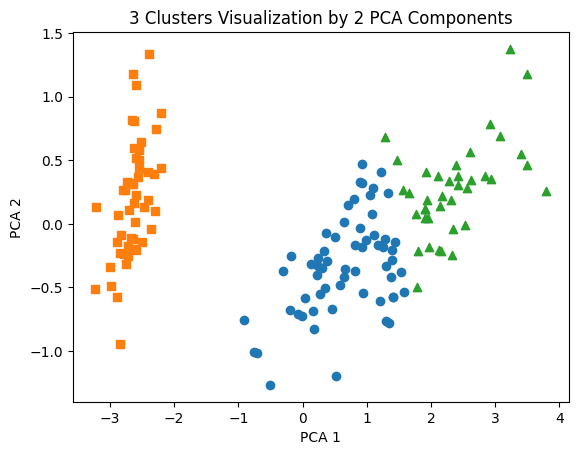

In [60]:
# 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF["cluster"] == 0].index
marker1_ind = irisDF[irisDF["cluster"] == 1].index
marker2_ind = irisDF[irisDF["cluster"] == 2].index

# 군집 값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o, s, ^로 마커 표시
plt.scatter(x = irisDF.loc[marker0_ind, "pca_x"], y = irisDF.loc[marker0_ind, "pca_y"], marker = 'o')
plt.scatter(x = irisDF.loc[marker1_ind, "pca_x"], y = irisDF.loc[marker1_ind, "pca_y"], marker = 's')
plt.scatter(x = irisDF.loc[marker2_ind, "pca_x"], y = irisDF.loc[marker2_ind, "pca_y"], marker = '^')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("3 Clusters Visualization by 2 PCA Components")
plt.show()

## 군집화 알고리즘 테스트를 위한 데이터 생성

파라미터 설명
 - n_samples : 생성할 총 데이터의 개수.(디폴트는 100개)
 - n_features : 데이터의 피처 개수입니다. 시각화를 목표로 할 경우 2개로 설정해 보통 첫 번째 피처는 x 좌표, 두 번째 피처는 y 좌표상에 표현합니다
 - centers : int 값, 예를 들어 3으로 설정하면 군집의 개수를 나타냅니다. 그렇지 않고 ndarray 형태로 표현할 경우 개별 군집 중심점의 좌표를 의미합니다
 - cluster_std : 생성될 군집 데이터의 표준 편차를 의미합니다. 만일 float 값 0.8과 같은 형태로 지정하면 구집 내에서 데이터가 표준편차 0.8을 가진 값으로 만들어집니다. [0.8, 1.2, 0.6]과 같은 형태로 표현되면 3개의 군집에서 첫 번째 군집 내 데이터의 표준편차는 0.8, 두 번째 군집 내 데이터의 표준 편차는 1.2, 세 번째 군집 내 데이터의 표준편차는 0.6으로 만듭니다. 군집별로 서로 다른 표준 편차를 가진 데이터 세트를 만들 때 사용합니다

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

x, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)
print(x.shape, y.shape)

# y target 값의 분포를 확인
unique, counts = np.unique(y, return_counts = True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [62]:
import pandas as pd

clusterDF = pd.DataFrame(data = x, columns = ["ftr1", "ftr2"])
clusterDF["target"] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


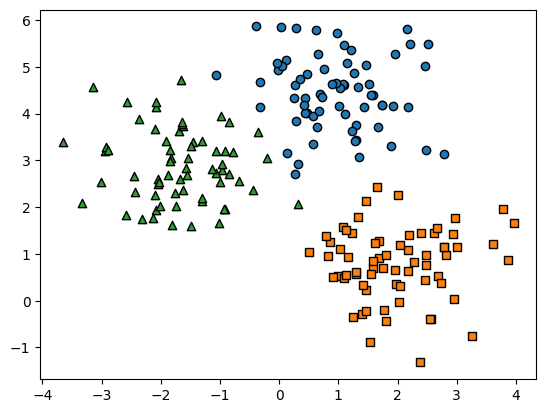

In [63]:
target_list = np.unique(y)
# 각 타깃별 산점도의 마커 값
markers = ["o", "s", "^", "P", "D", "H", "x"]
# 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0,1,2]
# target = 0, target = 1, target = 2로 scatter plot을 marker 별로 생성
for target in target_list:
    target_cluster = clusterDF[clusterDF["target"] == target]
    plt.scatter(x = target_cluster["ftr1"], y = target_cluster["ftr2"], edgecolor = "k", marker = markers[target])

plt.show()

[1 2 2 1 2 1 0 0 2 1 2 1 2 2 2 1 0 0 2 1 1 0 2 2 1 2 0 1 1 1 2 2 1 2 0 0 2
 0 0 1 0 1 1 1 2 2 2 1 2 2 2 0 1 1 1 1 0 0 2 2 1 1 2 0 0 1 0 0 1 0 0 2 2 1
 2 1 0 0 0 1 1 2 2 0 0 2 2 1 2 0 1 1 0 2 0 2 2 1 1 0 0 2 1 2 1 2 0 2 1 0 2
 1 0 1 2 2 2 0 1 1 0 0 1 2 0 2 1 0 1 2 1 0 0 0 2 0 0 2 0 1 1 1 2 0 0 2 1 1
 0 2 0 1 1 1 2 0 0 0 2 2 0 1 1 1 2 2 0 1 0 0 2 0 2 0 1 1 2 1 2 0 2 1 0 0 0
 2 1 0 2 2 1 1 0 0 0 0 1 0 2 0]
         ftr1      ftr2  target  kmeans_label
0   -1.692427  3.622025       2             1
1    0.697940  4.428867       0             2
2    1.100228  4.606317       0             2
3   -1.448724  3.384245       2             1
4    1.214861  5.364896       0             2
..        ...       ...     ...           ...
195  2.956576  0.033718       1             0
196 -2.074113  4.245523       2             1
197  2.783411  1.151438       1             0
198  1.226724  3.620511       0             2
199  1.474790 -0.209028       1             0

[200 rows x 4 columns]
[[ 1.95763312  0.

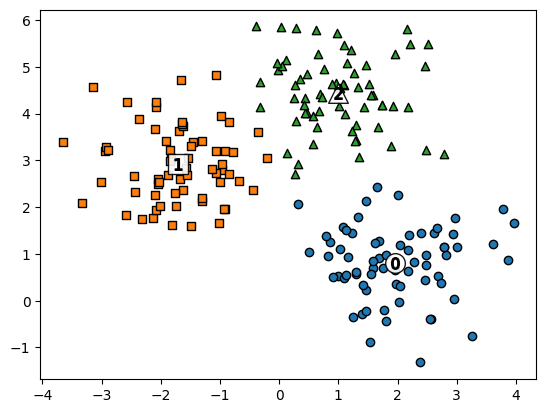

In [64]:
# KMeans 객체를 이용해 x 데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters = 3, init = "k-means++", max_iter = 200, random_state = 0)
cluster_labels = kmeans.fit_predict(x)
clusterDF["kmeans_label"] = cluster_labels

print(cluster_labels)
print(clusterDF)

# cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ["o", "s", "^", "P", "D", "H", "x"]

print(centers)

# 군집화된 label 유형별로 iteration하면서 marker 별로 scatter plot 수행
for label in unique_labels:
    label_cluster = clusterDF[clusterDF["kmeans_label"] == label]
    center_x_y = centers[label]
    plt.scatter(x = label_cluster["ftr1"], y = label_cluster["ftr2"], edgecolor = "k", marker = markers[label])
    plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 200, color = "white", alpha = 0.9, edgecolor = "k", marker = markers[label])
    plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 70, color = "k", edgecolor = "k", marker = "$%d$" % label)

plt.show()

In [65]:
print(clusterDF.groupby("target")["kmeans_label"].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


## 실루엣 분석의 개요

군집화 평가 방법으로 실루엣 분석이 있습니다.

실루엣 분석은 각 군집 간의 거리가 얼마나 효율적으로 분리돼 있는지를 나타냅니다. 효율적으로 잘 분리됐다는 것은 다른 군집과의 거리는 떨어져 있고 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐 있다는 의미입니다. 군집화가 잘 될수록 개별 군집은 비슷한 정도의 여유공간을 가지고 떨어져 있을 것입니다.

실루엣 분석은 실루엣 계수를 기반으로 합니다. 실루엣 계수는 개별 데이터가 가지는 군집화 지표입니다. 개별 데이터가 가지는 실루엣 계수는 해당 데이터가 같은 군집 내의 데이터와 얼마나 가깝게 군집화돼 있고, 다른 군집에 있는 데이터와는 얼마나 멀리 분리돼 있는지를 나타내는 지표입니다

실루엣 계수는 -1에서 1 사이의 값을 가지며, 1로 가까워질수록 근처의 군집과 더 멀리 떨어져 있다는 것이고 0에 가까울수록 근처의 군집과 가까워진다는 것입니다. - 값은 아예 다른 군집에 데이터 포인트가 할당됐음을 뜻합니다

좋은 군집화가 되려면 다음 기준 조건을 만족해야 합니다
 - 전체 실루엣 계수의 평균값. 즉, 사이킷런의 silhouette_score() 값은 0 ~ 1 사이의 값을 가지며, 1에 가까울수록 좋습니다
 - 하지만 전체 실루엣 계수의 평균값과 더불어 개별 군집의 평균값의 편차가 크지 않아야 합니다. 즉, 개별 군집의 실루엣 계수 평균값이 전체 실루엣 계수의 평균값에서 크게 벗어나지 않는 것이 중요합니다. 만약 전체 실루엣 계수의 평균값은 높지만, 특정 군집의 실루엣 계수 평균값만 유난히 높고 다른 군집들의 실루엣 계수 평균값은 낮으면 좋은 군집화 조건이 아닙니다.

## 붓꽃 데이터 세를 이용힌 군집 평가

In [66]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_svmlight_files
from sklearn.cluster import KMeans
# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
irisDF = pd.DataFrame(data = iris.data, columns = feature_names)
kmeans = KMeans(n_clusters = 3, init = "k-means++", max_iter = 300, random_state = 0).fit(irisDF)
irisDF["cluster"] = kmeans.labels_

# iris의 모든 개별 데이터에 실루엣 계수 값을 구함
score_samples = silhouette_samples(iris.data, irisDF["cluster"])
print("silhouette_samples() return 값의 shape", score_samples.shape)

# irisDF에 실루엣 계수 칼럼 추가
irisDF["silhouette_coeff"] = score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함
average_score = silhouette_score(iris.data, irisDF["cluster"])
print("붓꽃 데이터 세트 실루엣 분석 결과 : {0:.3f}".format(average_score))

irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 실루엣 분석 결과 : 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [67]:
irisDF.groupby("cluster")["silhouette_coeff"].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842
